In [ ]:
from sklearn import datasets
iris=datasets.load_iris()

Train samples: 105 | Val samples: 22 | Test samples: 23

Early stopping at epoch 1159 (best val loss: 0.0345)
W1:
 [[-0.25926712 -0.63353764  0.64248979  0.15904098 -0.11476109  0.0777755 ]
 [ 0.7525938   1.34263919 -1.23066244 -0.49345219  0.69799067  0.18870555]
 [-0.93927468 -1.76027888  1.23293822  1.57745054 -1.17654653 -1.68712347]
 [-1.09915026 -1.65308264  1.51504273  2.58877109 -1.2749847  -3.3541121 ]]
b:
 [-0.41108629 -1.55619918  1.15752285 -2.64972129 -0.31450658  2.93065093]

 W2 
 [[ 0.83666855 -1.19774281 -1.92506874]
 [ 2.34839229 -3.22806548 -2.27638311]
 [-2.87654305  1.59390125  1.35864403]
 [-1.87715286 -3.37625128  2.71023165]
 [ 1.60543677 -1.25233394 -2.73243278]
 [-0.13213229  3.9501547  -3.5657678 ]]
b2:
 [-1.0334137  -1.24763815 -0.63698515]

Model Performance
Training Accuracy:   97.14%
Validation Accuracy: 86.36%
Testing Accuracy:    95.65%


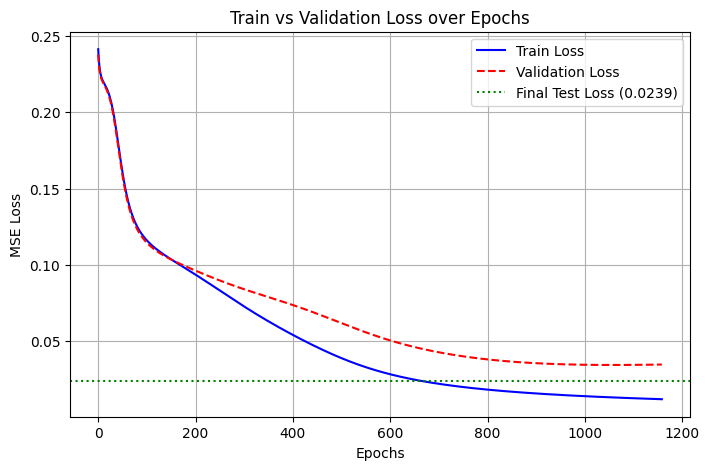

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 1. Load Iris dataset
iris = datasets.load_iris()
X = iris.data          
y = iris.target       
y_onehot = np.eye(3)[y]
# 2. Split into Train,test and valdate
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp.argmax(axis=1)
)
# Scale features 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"Train samples: {len(X_train)} | Val samples: {len(X_val)} | Test samples: {len(X_test)}\n")
# 3. Network Setup
np.random.seed(42)
input_dim = 4
hidden_dim = 6
output_dim = 3
w1 = np.random.randn(input_dim, hidden_dim) * 0.1
b1 = np.zeros(hidden_dim)
w2 = np.random.randn(hidden_dim, output_dim) * 0.1
b2 = np.zeros(output_dim)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def derivative_sigmoid(a):
    return a * (1 - a)
# Forward pass helper function
def predict(X_input):
    a1 = sigmoid(np.dot(X_input, w1) + b1)
    a2 = sigmoid(np.dot(a1, w2) + b2)
    return a2
# 4. Training Parameters
epochs = 1500
lr = 0.01
train_losses = []
val_losses = []
# Step 1: Early stopping setup
best_val_loss = np.inf
patience = 100       
patience_counter = 0
best_weights = (w1.copy(), b1.copy(), 
w2.copy(), b2.copy())
# 5. Training Loop
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    train_loss = 0
    for i in range(len(X_train)):
        x = X_train[i]
        target = y_train[i]
        # Forward Pass
        h1 = (x @ w1) + b1
        a1 = sigmoid(h1)
        h2 = (a1 @ w2) + b2
        a2 = sigmoid(h2)
        train_loss += np.mean(np.square(target - a2))
        # Backpropagation
        o2 = (a2 - target) * derivative_sigmoid(a2)
        o1 = derivative_sigmoid(a1) * (w2 @ o2)
        # Weight updates
        w2 -= lr * np.outer(a1, o2)
        b2 -= lr * o2
        w1 -= lr * np.outer(x, o1)
        b1 -= lr * o1
    train_losses.append(train_loss / len(X_train))

    val_pred=predict(X_val)
    val_loss=np.mean(np.square(y_val-val_pred))
    val_losses.append(val_loss)
     # Step 1: Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = (w1.copy(), b1.copy(), w2.copy(), b2.copy())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.4f})")
            break

# Restore the best weights seen during training
w1, b1, w2, b2 = best_weights


#6 Print trainned/updated weight and bais
print("W1:\n",w1)
print("b:\n",b1)
print("\n W2 \n",w2)
print("b2:\n",b2)
#7 Print all three accuracy
train_pred=predict(X_train)
test_pred=predict(X_test)
train_acc = np.mean(np.argmax(train_pred, axis=1) == np.argmax(y_train, axis=1)) * 100
val_acc   = np.mean(np.argmax(val_pred,   axis=1) == np.argmax(y_val,   axis=1)) * 100
test_acc  = np.mean(np.argmax(test_pred,  axis=1) == np.argmax(y_test,  axis=1)) * 100
print("\nModel Performance")
print(f"Training Accuracy:   {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Testing Accuracy:    {test_acc:.2f}%")

# 8. Plot Loss Curves
final_test_loss = np.mean(np.square(y_test - test_pred))  # test_pred was computed in step 7

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="red", linestyle="--")
plt.axhline(final_test_loss, color="green", linestyle=":", label=f"Final Test Loss ({final_test_loss:.4f})")
plt.title("Train vs Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


Train samples: 105 | Val samples: 22 | Test samples: 23

Early stopping at epoch 1159 (best val loss: 0.0345)
W1:
 [[-0.25926712 -0.63353764  0.64248979  0.15904098 -0.11476109  0.0777755 ]
 [ 0.7525938   1.34263919 -1.23066244 -0.49345219  0.69799067  0.18870555]
 [-0.93927468 -1.76027888  1.23293822  1.57745054 -1.17654653 -1.68712347]
 [-1.09915026 -1.65308264  1.51504273  2.58877109 -1.2749847  -3.3541121 ]]
b:
 [-0.41108629 -1.55619918  1.15752285 -2.64972129 -0.31450658  2.93065093]

 W2 
 [[ 0.83666855 -1.19774281 -1.92506874]
 [ 2.34839229 -3.22806548 -2.27638311]
 [-2.87654305  1.59390125  1.35864403]
 [-1.87715286 -3.37625128  2.71023165]
 [ 1.60543677 -1.25233394 -2.73243278]
 [-0.13213229  3.9501547  -3.5657678 ]]
b2:
 [-1.0334137  -1.24763815 -0.63698515]

Model Performance
Training Accuracy:   97.14%
Validation Accuracy: 86.36%
Testing Accuracy:    95.65%


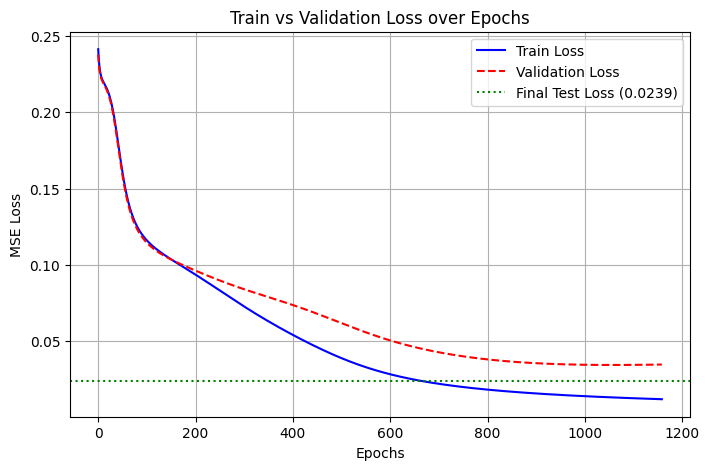

Early stopping at epoch 1251 (best val loss: 0.0409)
2-feature model test accuracy: 95.65%


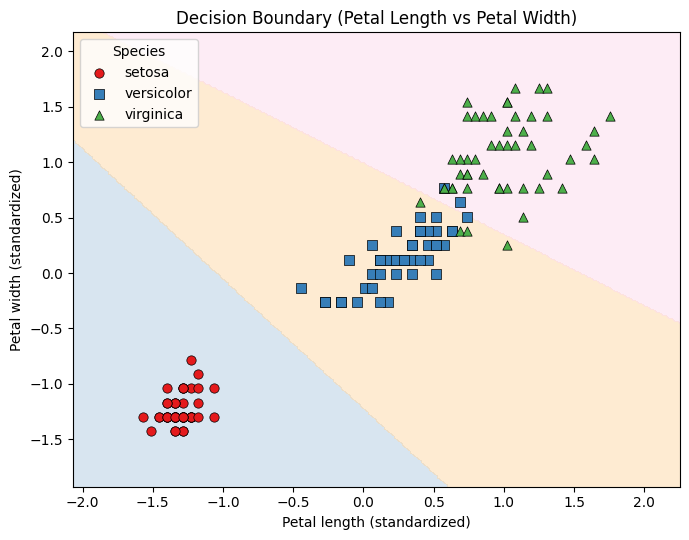

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
y_onehot = np.eye(3)[y]

# 2. Split into Train, Validation, Test (4-feature model)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp.argmax(axis=1)
)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"Train samples: {len(X_train)} | Val samples: {len(X_val)} | Test samples: {len(X_test)}\n")

# 3. Shared hyperparameters / activation functions (used by every model we train)
np.random.seed(42)
hidden_dim = 6
output_dim = 3
epochs = 1500
lr = 0.01
patience = 100

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def derivative_sigmoid(a):
    return a * (1 - a)

# 4. One reusable trainer — used for BOTH the 4-feature model and the
#    2-feature model below, so the training loop is written only once.
def train_network(X_tr, y_tr, X_va, y_va, input_dim, track_losses=False):
    np.random.seed(42)
    w1_ = np.random.randn(input_dim, hidden_dim) * 0.1
    b1_ = np.zeros(hidden_dim)
    w2_ = np.random.randn(hidden_dim, output_dim) * 0.1
    b2_ = np.zeros(output_dim)

    def predict_(X_input):
        a1 = sigmoid(np.dot(X_input, w1_) + b1_)
        a2 = sigmoid(np.dot(a1, w2_) + b2_)
        return a2

    best_val_loss_ = np.inf
    patience_counter_ = 0
    best_weights_ = (w1_.copy(), b1_.copy(), w2_.copy(), b2_.copy())
    train_losses_, val_losses_ = [], []

    for epoch in range(epochs):
        train_loss_ = 0
        for i in range(len(X_tr)):
            x = X_tr[i]
            target = y_tr[i]
            h1 = (x @ w1_) + b1_
            a1 = sigmoid(h1)
            h2 = (a1 @ w2_) + b2_
            a2 = sigmoid(h2)
            train_loss_ += np.mean(np.square(target - a2))
            o2 = (a2 - target) * derivative_sigmoid(a2)
            o1 = derivative_sigmoid(a1) * (w2_ @ o2)
            w2_ -= lr * np.outer(a1, o2)
            b2_ -= lr * o2
            w1_ -= lr * np.outer(x, o1)
            b1_ -= lr * o1

        val_loss_ = np.mean(np.square(y_va - predict_(X_va)))

        if track_losses:
            train_losses_.append(train_loss_ / len(X_tr))
            val_losses_.append(val_loss_)

        if val_loss_ < best_val_loss_:
            best_val_loss_ = val_loss_
            patience_counter_ = 0
            best_weights_ = (w1_.copy(), b1_.copy(), w2_.copy(), b2_.copy())
        else:
            patience_counter_ += 1
            if patience_counter_ >= patience:
                print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss_:.4f})")
                break

    w1_, b1_, w2_, b2_ = best_weights_
    return w1_, b1_, w2_, b2_, predict_, train_losses_, val_losses_

# 5. Train the 4-feature model (loss curves tracked for plotting)
w1, b1, w2, b2, predict, train_losses, val_losses = train_network(
    X_train, y_train, X_val, y_val, input_dim=4, track_losses=True
)

# 6. Print trained weights & biases
print("W1:\n", w1)
print("b1:\n", b1)
print("\nW2:\n", w2)
print("b2:\n", b2)

# 7. Print all three accuracies
train_pred = predict(X_train)
val_pred = predict(X_val)
test_pred = predict(X_test)
train_acc = np.mean(np.argmax(train_pred, axis=1) == np.argmax(y_train, axis=1)) * 100
val_acc = np.mean(np.argmax(val_pred, axis=1) == np.argmax(y_val, axis=1)) * 100
test_acc = np.mean(np.argmax(test_pred, axis=1) == np.argmax(y_test, axis=1)) * 100

print("\nModel Performance")
print(f"Training Accuracy:   {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Testing Accuracy:    {test_acc:.2f}%")

# 8. Plot Loss Curves
final_test_loss = np.mean(np.square(y_test - test_pred))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="red", linestyle="--")
plt.axhline(final_test_loss, color="green", linestyle=":", label=f"Final Test Loss ({final_test_loss:.4f})")
plt.title("Train vs Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()
# 9. Decision Boundary Visualization (2-feature model)

X_2f = iris.data[:, [2, 3]]  # petal length, petal width

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_2f, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, random_state=42, stratify=y2_temp.argmax(axis=1)
)

scaler_2f = StandardScaler()
X2_train = scaler_2f.fit_transform(X2_train)
X2_val = scaler_2f.transform(X2_val)
X2_test = scaler_2f.transform(X2_test)

w1_2f, b1_2f, w2_2f, b2_2f, predict_2f, _, _ = train_network(
    X2_train, y2_train, X2_val, y2_val, input_dim=2
)

test_pred_2f = predict_2f(X2_test)
test_acc_2f = np.mean(np.argmax(test_pred_2f, axis=1) == np.argmax(y2_test, axis=1)) * 100
print(f"\n2-feature model test accuracy: {test_acc_2f:.2f}%")

# Mesh grid over standardized petal length/width space
all_X_2f = np.vstack([X2_train, X2_val, X2_test])
all_y_2f = np.concatenate([
    np.argmax(y2_train, axis=1),
    np.argmax(y2_val, axis=1),
    np.argmax(y2_test, axis=1)
])

x_min, x_max = all_X_2f[:, 0].min() - 0.5, all_X_2f[:, 0].max() + 0.5
y_min, y_max = all_X_2f[:, 1].min() - 0.5, all_X_2f[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.argmax(predict_2f(grid), axis=1).reshape(xx.shape)

plt.figure(figsize=(7, 5.5))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.Pastel1, levels=[-0.5, 0.5, 1.5, 2.5])

markers = ['o', 's', '^']
for cls in range(3):
    mask = all_y_2f == cls
    plt.scatter(all_X_2f[mask, 0], all_X_2f[mask, 1], label=iris.target_names[cls],
                edgecolor='black', linewidth=0.5, s=45, marker=markers[cls],
                color=plt.cm.Set1(cls))
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title("Decision Boundary (Petal Length vs Petal Width)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

Train samples: 105 | Val samples: 22 | Test samples: 23

Early stopping at epoch 1159 (best val loss: 0.0345)
W1:
 [[-0.25926712 -0.63353764  0.64248979  0.15904098 -0.11476109  0.0777755 ]
 [ 0.7525938   1.34263919 -1.23066244 -0.49345219  0.69799067  0.18870555]
 [-0.93927468 -1.76027888  1.23293822  1.57745054 -1.17654653 -1.68712347]
 [-1.09915026 -1.65308264  1.51504273  2.58877109 -1.2749847  -3.3541121 ]]
b1:
 [-0.41108629 -1.55619918  1.15752285 -2.64972129 -0.31450658  2.93065093]

W2:
 [[ 0.83666855 -1.19774281 -1.92506874]
 [ 2.34839229 -3.22806548 -2.27638311]
 [-2.87654305  1.59390125  1.35864403]
 [-1.87715286 -3.37625128  2.71023165]
 [ 1.60543677 -1.25233394 -2.73243278]
 [-0.13213229  3.9501547  -3.5657678 ]]
b2:
 [-1.0334137  -1.24763815 -0.63698515]

Model Performance
Training Accuracy:   97.14%
Validation Accuracy: 86.36%
Testing Accuracy:    95.65%


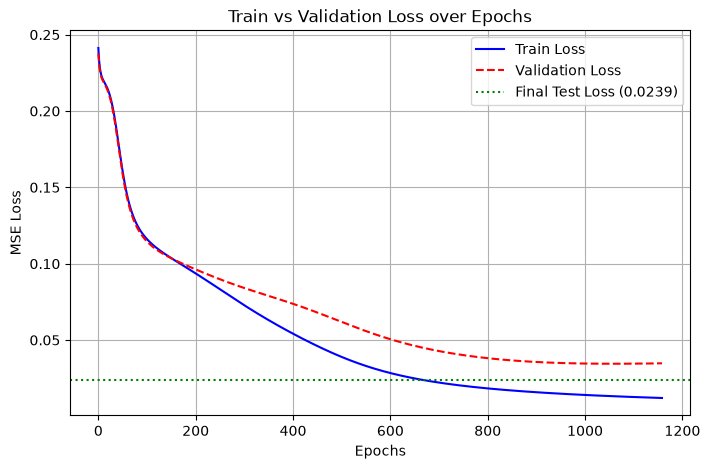

Early stopping at epoch 1251 (best val loss: 0.0409)

2-feature model test accuracy: 95.65%


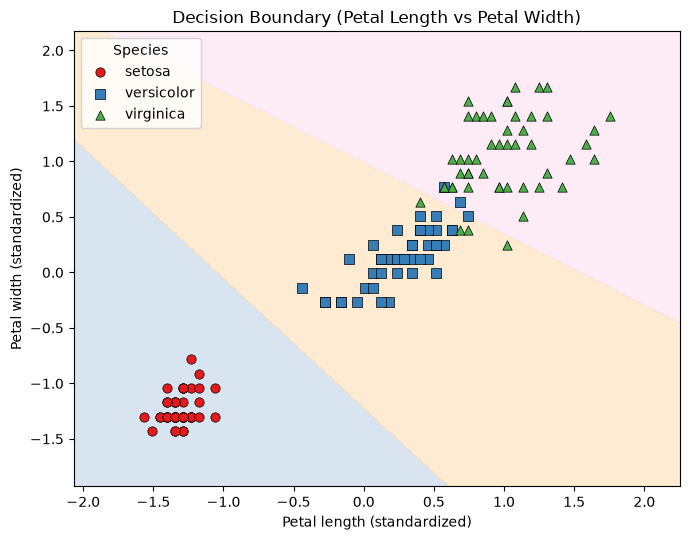

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
y_onehot = np.eye(3)[y]

# 2. Split into Train, Validation, Test (4-feature model)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp.argmax(axis=1)
)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"Train samples: {len(X_train)} | Val samples: {len(X_val)} | Test samples: {len(X_test)}\n")

# 3. Shared hyperparameters / activation functions (used by every model we train)
np.random.seed(42)
hidden_dim = 6
output_dim = 3
epochs = 1500
lr = 0.01
patience = 100

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def derivative_sigmoid(a):
    s=sigmoid(a)
    return s * (1 - s)

# 4. One reusable trainer — used for BOTH the 4-feature model and the
#    2-feature model below, so the training loop is written only once.
def train_network(X_tr, y_tr, X_va, y_va, input_dim, track_losses=False):
    np.random.seed(42)
    w1_ = np.random.randn(input_dim, hidden_dim) * 0.1
    b1_ = np.zeros(hidden_dim)
    w2_ = np.random.randn(hidden_dim, output_dim) * 0.1
    b2_ = np.zeros(output_dim)

    def predict_(X_input):
        a1 = sigmoid(np.dot(X_input, w1_) + b1_)
        a2 = sigmoid(np.dot(a1, w2_) + b2_)
        return a2

    best_val_loss_ = np.inf
    patience_counter_ = 0
    best_weights_ = (w1_.copy(), b1_.copy(), w2_.copy(), b2_.copy())
    train_losses_, val_losses_ = [], []

    for epoch in range(epochs):
        train_loss_ = 0
        for i in range(len(X_tr)):
            x = X_tr[i]
            target = y_tr[i]
            h1 = (x @ w1_) + b1_
            a1 = sigmoid(h1)
            h2 = (a1 @ w2_) + b2_
            a2 = sigmoid(h2)
            train_loss_ += np.mean(np.square(target - a2))
            o2 = (a2 - target) * derivative_sigmoid(h2)
            o1 = derivative_sigmoid(h1) * (w2_ @ o2)
            w2_ -= lr * np.outer(a1, o2)
            b2_ -= lr * o2
            w1_ -= lr * np.outer(x, o1)
            b1_ -= lr * o1

        val_loss_ = np.mean(np.square(y_va - predict_(X_va)))

        if track_losses:
            train_losses_.append(train_loss_ / len(X_tr))
            val_losses_.append(val_loss_)

        if val_loss_ < best_val_loss_:
            best_val_loss_ = val_loss_
            patience_counter_ = 0
            best_weights_ = (w1_.copy(), b1_.copy(), w2_.copy(), b2_.copy())
        else:
            patience_counter_ += 1
            if patience_counter_ >= patience:
                print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss_:.4f})")
                break

    w1_, b1_, w2_, b2_ = best_weights_
    return w1_, b1_, w2_, b2_, predict_, train_losses_, val_losses_

# 5. Train the 4-feature model (loss curves tracked for plotting)
w1, b1, w2, b2, predict, train_losses, val_losses = train_network(
    X_train, y_train, X_val, y_val, input_dim=4, track_losses=True
)

# 6. Print trained weights & biases
print("W1:\n", w1)
print("b1:\n", b1)
print("\nW2:\n", w2)
print("b2:\n", b2)

# 7. Print all three accuracies
train_pred = predict(X_train)
val_pred = predict(X_val)
test_pred = predict(X_test)
train_acc = np.mean(np.argmax(train_pred, axis=1) == np.argmax(y_train, axis=1)) * 100
val_acc = np.mean(np.argmax(val_pred, axis=1) == np.argmax(y_val, axis=1)) * 100
test_acc = np.mean(np.argmax(test_pred, axis=1) == np.argmax(y_test, axis=1)) * 100

print("\nModel Performance")
print(f"Training Accuracy:   {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Testing Accuracy:    {test_acc:.2f}%")

# 8. Plot Loss Curves
final_test_loss = np.mean(np.square(y_test - test_pred))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="red", linestyle="--")
plt.axhline(final_test_loss, color="green", linestyle=":", label=f"Final Test Loss ({final_test_loss:.4f})")
plt.title("Train vs Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()
# 9. Decision Boundary Visualization (2-feature model)

X_2f = iris.data[:, [2, 3]]  # petal length, petal width

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_2f, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, random_state=42, stratify=y2_temp.argmax(axis=1)
)

scaler_2f = StandardScaler()
X2_train = scaler_2f.fit_transform(X2_train)
X2_val = scaler_2f.transform(X2_val)
X2_test = scaler_2f.transform(X2_test)

w1_2f, b1_2f, w2_2f, b2_2f, predict_2f, _, _ = train_network(
    X2_train, y2_train, X2_val, y2_val, input_dim=2
)

test_pred_2f = predict_2f(X2_test)
test_acc_2f = np.mean(np.argmax(test_pred_2f, axis=1) == np.argmax(y2_test, axis=1)) * 100
print(f"\n2-feature model test accuracy: {test_acc_2f:.2f}%")

# Mesh grid over standardized petal length/width space
all_X_2f = np.vstack([X2_train, X2_val, X2_test])
all_y_2f = np.concatenate([
    np.argmax(y2_train, axis=1),
    np.argmax(y2_val, axis=1),
    np.argmax(y2_test, axis=1)
])

x_min, x_max = all_X_2f[:, 0].min() - 0.5, all_X_2f[:, 0].max() + 0.5
y_min, y_max = all_X_2f[:, 1].min() - 0.5, all_X_2f[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.argmax(predict_2f(grid), axis=1).reshape(xx.shape)

plt.figure(figsize=(7, 5.5))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.Pastel1, levels=[-0.5, 0.5, 1.5, 2.5])

markers = ['o', 's', '^']
for cls in range(3):
    mask = all_y_2f == cls
    plt.scatter(all_X_2f[mask, 0], all_X_2f[mask, 1], label=iris.target_names[cls],
                edgecolor='black', linewidth=0.5, s=45, marker=markers[cls],
                color=plt.cm.Set1(cls))
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title("Decision Boundary (Petal Length vs Petal Width)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()